In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd, numpy as np

fish = pd.read_csv('./Fish2.csv')

# 입력(무게·길이·대각선·높이·너비), 타깃(종)
fish_input  = fish[['Weight','Length','Diagonal','Height','Width']].to_numpy()
fish_target = fish['Species'].to_numpy()

from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
    fish_input, fish_target, random_state=42)

ss = StandardScaler()
train_scaled = ss.fit_transform(train_input) #학습하고 바꿈
test_scaled  = ss.transform(test_input) #학습 안하고 바꿈

kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.predict_proba(test_scaled[:5])

[[0.         0.         1.         0.         0.         0.
  0.        ]
 [0.         0.         0.         0.         0.         1.
  0.        ]
 [0.         0.         0.         1.         0.         0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]
 [0.         0.         0.66666667 0.         0.33333333 0.
  0.        ]]


In [8]:
print(fish_target)

['Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream'
 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Bream' 'Roach'
 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach'
 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach' 'Roach'
 'Roach' 'Whitefish' 'Whitefish' 'Whitefish' 'Whitefish' 'Whitefish'
 'Whitefish' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki'
 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Parkki' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'
 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch' 'Perch'

In [9]:
print(kn.classes_)

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']


In [10]:
#로지스틱 회귀 -> 분류

from sklearn.linear_model import LogisticRegression

bream_smelt_indexes = (train_target=='bream') | (train_target =='smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

In [15]:
# 1. LogisticRegression 임포트
from sklearn.linear_model import LogisticRegression

# 2. 도미('Bream')와 빙어('Smelt') 행만 골라내기 (불리언 인덱싱)
bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

# 3. 로지스틱 회귀 모델 생성 및 훈련
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

# 정상 훈련 여부 확인
print("로지스틱 회귀 모델 훈련 완료!")

print(lr.classes_)
print(lr.coef_)

로지스틱 회귀 모델 훈련 완료!
['Bream' 'Smelt']
[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]]


In [18]:
decisions = lr.decision_function(train_bream_smelt[:5])
print(decisions)


[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [19]:
from scipy.special import expit
# z를 시그모이드 함수에 통과
print(expit(decisions))

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48729 (\N{HANGUL SYLLABLE BING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


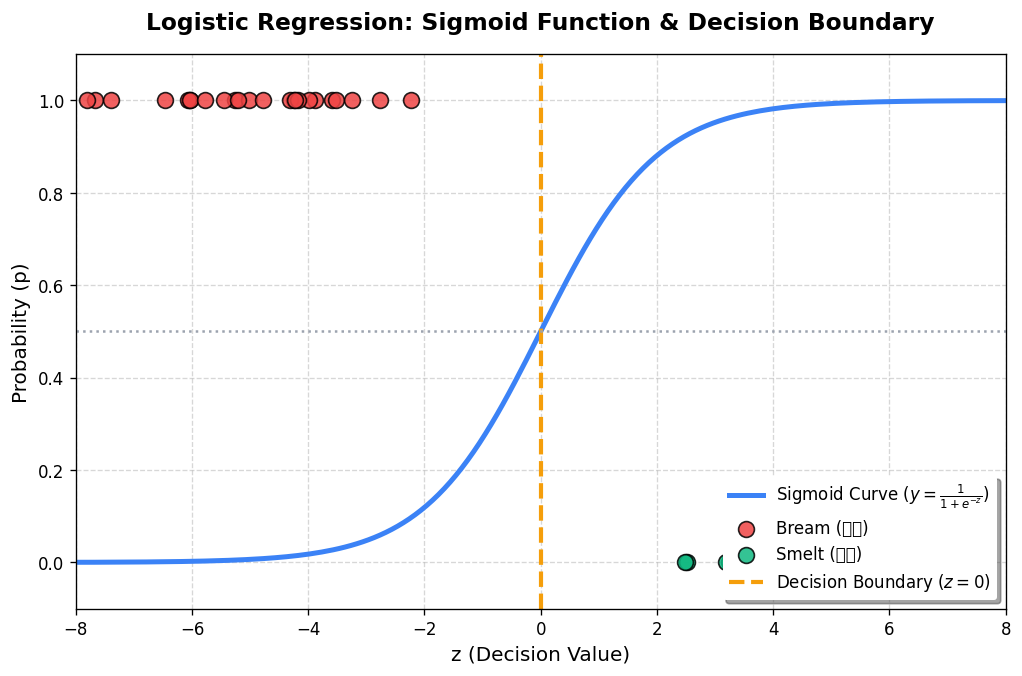

In [20]:
# ai 시각화 : 결정 경계, 시그모이드 함수 시각화
import numpy as np
import matplotlib.pyplot as plt

# 1. 시그모이드 함수 정의
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 2. 모델의 decision_function을 통해 각 데이터의 z값(결정 점수) 계산
z_values = lr.decision_function(train_bream_smelt)

# 3. 시그모이드 곡선을 그리기 위한 z 범위 설정
z_range = np.linspace(-10, 10, 200)
phi = sigmoid(z_range)

# 4. 고급스러운 스타일로 그래프 설정
plt.figure(figsize=(10, 6), dpi=120)

# 시그모이드 곡선 그리기 (블루 테마)
plt.plot(z_range, phi, color='#3b82f6', linewidth=3, label='Sigmoid Curve ($y = \\frac{1}{1 + e^{-z}}$)')

# 실제 데이터 포인트 매핑 (도미: Red, 빙어: Emerald Green)
is_bream = (target_bream_smelt == 'Bream')
is_smelt = (target_bream_smelt == 'Smelt')

# 도미(Bream) -> Y=1 선상에 매핑
plt.scatter(z_values[is_bream], np.ones(np.sum(is_bream)), 
            color='#ef4444', s=90, edgecolor='black', alpha=0.85, zorder=5, label='Bream (도미)')

# 빙어(Smelt) -> Y=0 선상에 매핑
plt.scatter(z_values[is_smelt], np.zeros(np.sum(is_smelt)), 
            color='#10b981', s=90, edgecolor='black', alpha=0.85, zorder=5, label='Smelt (빙어)')

# 5. 결정 경계선 (Decision Boundary: z = 0, 확률 p = 0.5)
plt.axvline(x=0, color='#f59e0b', linestyle='--', linewidth=2.5, label='Decision Boundary ($z = 0$)')
plt.axhline(y=0.5, color='#9ca3af', linestyle=':', linewidth=1.5)

# 그래프 꾸미기
plt.title('Logistic Regression: Sigmoid Function & Decision Boundary', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('z (Decision Value)', fontsize=12)
plt.ylabel('Probability (p)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='none', shadow=True)
plt.xlim(-8, 8)
plt.ylim(-0.1, 1.1)

plt.show()


c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48729 (\N{HANGUL SYLLABLE BING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\금정산2-PC15\Desktop\busan_solution_in_buva\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


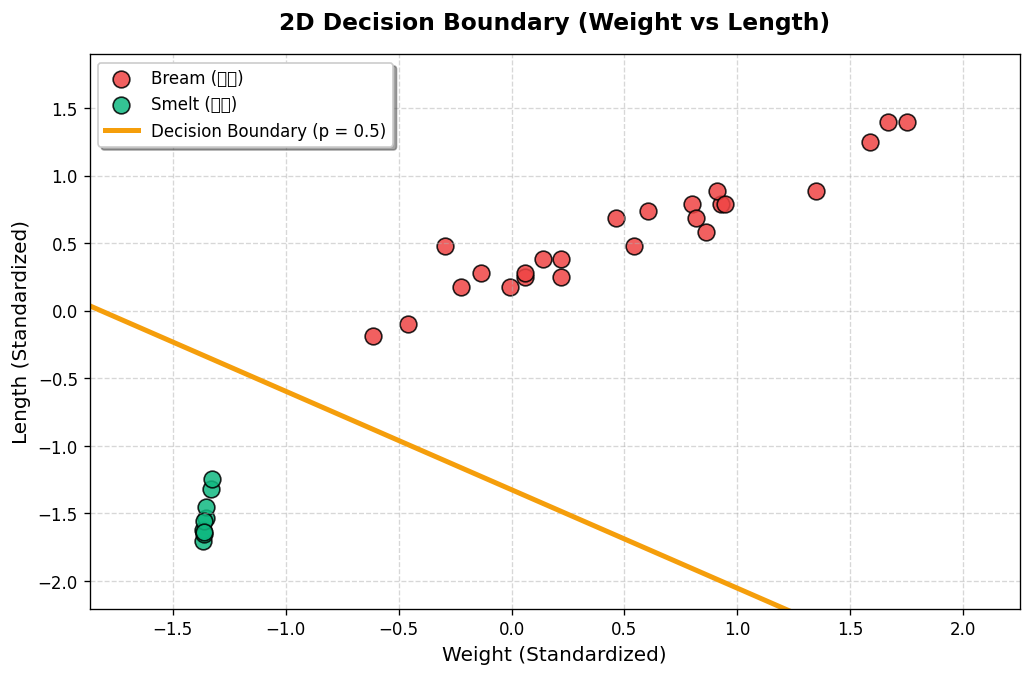

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# 1. 2D 시각화를 위해 대표 특성인 무게(Weight)와 길이(Length) 2개만 선택
X_2d = train_input[:, [0, 1]]
y_2d = train_target

# 도미와 빙어 필터링
bream_smelt_indexes_2d = (y_2d == 'Bream') | (y_2d == 'Smelt')
X_2d_filtered = X_2d[bream_smelt_indexes_2d]
y_2d_filtered = y_2d[bream_smelt_indexes_2d]

# 스케일 표준화
ss_2d = StandardScaler()
X_2d_scaled = ss_2d.fit_transform(X_2d_filtered)

# 2D 로지스틱 회귀 모델 학습 (도미 = 1, 빙어 = 0)
lr_2d = LogisticRegression()
y_numeric = np.where(y_2d_filtered == 'Bream', 1, 0)
lr_2d.fit(X_2d_scaled, y_numeric)

# 2. 결정 경계선 (z = a*x1 + b*x2 + c = 0) 도출
# x2 = -(a*x1 + c) / b
coef = lr_2d.coef_[0]
intercept = lr_2d.intercept_[0]

x1_range = np.linspace(X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5, 100)
x2_boundary = -(coef[0] * x1_range + intercept) / coef[1]

# 3. 시각화
plt.figure(figsize=(10, 6), dpi=120)

# 도미와 빙어 분포 플롯
plt.scatter(X_2d_scaled[y_numeric == 1, 0], X_2d_scaled[y_numeric == 1, 1], 
            color='#ef4444', s=100, edgecolor='black', alpha=0.85, label='Bream (도미)')
plt.scatter(X_2d_scaled[y_numeric == 0, 0], X_2d_scaled[y_numeric == 0, 1], 
            color='#10b981', s=100, edgecolor='black', alpha=0.85, label='Smelt (빙어)')

# 결정 경계선 플롯
plt.plot(x1_range, x2_boundary, color='#f59e0b', linewidth=3, label='Decision Boundary (p = 0.5)')

# 그래프 데코레이션
plt.title('2D Decision Boundary (Weight vs Length)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Weight (Standardized)', fontsize=12)
plt.ylabel('Length (Standardized)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.xlim(X_2d_scaled[:, 0].min() - 0.5, X_2d_scaled[:, 0].max() + 0.5)
plt.ylim(X_2d_scaled[:, 1].min() - 0.5, X_2d_scaled[:, 1].max() + 0.5)

plt.show()


#다중 분류
- softmax 함수
  - e 지수 함수를 함수로 적용
  - 정규화 -> 모든 확률의 합은 100%되게끔. 하지만 가장 큰 점수를 극대화 시키는 함수

In [22]:
lr = LogisticRegression(C=20, max_iter=1000)
# C(규제의 역수) 값은 클수록 규제가 약하고 자유도가 높음
# max_iter는 한번에 결정경계를 못 찾기 때문에 반복 학습 과정을 거침(경사하강법) 최대 몇번 할 것인가?
lr.fit(train_scaled, train_target)

print(lr.classes_)
# ['Bream' 'Parkki' 'Perch' 'Pike'
#  'Roach' 'Smelt' 'Whitefish']

proba = lr.predict_proba(test_scaled[:3])
print(proba.round(3))
# train: 0.9328  test: 0.9250

['Bream' 'Parkki' 'Perch' 'Pike' 'Roach' 'Smelt' 'Whitefish']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]]


In [25]:
decision = lr.decision_function(test_scaled[:5])
print(decisions.shape)

(5,)


In [26]:
from scipy.special import softmax
proba_from_softmax =  softmax(decision, axis = 1)
proba_from_softmax.round(3) # 결과가 로지스틱 회귀의 결과와 같다.
# 다항 분류의 경우 softmax를 사용한다.


array([[0.   , 0.014, 0.842, 0.   , 0.135, 0.007, 0.003],
       [0.   , 0.003, 0.044, 0.   , 0.007, 0.946, 0.   ],
       [0.   , 0.   , 0.034, 0.934, 0.015, 0.016, 0.   ],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.   , 0.076],
       [0.   , 0.   , 0.904, 0.002, 0.089, 0.002, 0.001]])

In [27]:
proba_df = pd.DataFrame(
    lr.predict_proba(test_scaled[:3]).round(3),
    columns=lr.classes_
)
proba_df

,Bream,Parkki,Perch,Pike,Roach,Smelt,Whitefish
0,0.0,0.014,0.842,0.000,0.135,0.007,0.003
1,0.0,0.003,0.044,0.000,0.007,0.946,0.000
2,0.0,0.000,0.034,0.934,0.015,0.016,0.000


In [28]:
#평가
lr.score(test_scaled, test_target) # 정확도 92.5%

0.925

In [29]:
from sklearn.metrics import confusion_matrix
y_ture = [ 1,0,1,1,1,0,0,1,1] #실제 정답
y_pred = [ 0,0,0,1,1,0,0,1,1] 

confusion_matrix(y_ture,y_pred)

array([[3, 0],
       [2, 4]])

In [31]:
from sklearn.metrics import classification_report
print(classification_report(y_ture, y_pred))

              precision    recall  f1-score   support

           0       0.60      1.00      0.75         3
           1       1.00      0.67      0.80         6

    accuracy                           0.78         9
   macro avg       0.80      0.83      0.78         9
weighted avg       0.87      0.78      0.78         9



In [33]:

import seaborn as sns
titanic = sns.load_dataset('titanic')

# 기본 전처리
titanic_clean = titanic[['survived','pclass','sex','age','sibsp','parch','fare']].dropna()

# 인코딩
titanic_clean = pd.get_dummies(titanic_clean, columns=['sex'], drop_first=True)

X = titanic_clean.drop('survived', axis=1).values # ㅌ : 7개 특성
y = titanic_clean['survived'].values # y : 생존 여부

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, stratify=y)  # stratify로 불균형 비율 유지

ss = StandardScaler() # 표준화
X_train_s = ss.fit_transform(X_train)
X_test_s  = ss.transform(X_test)

print("생존:", y.sum(), "사망:", len(y) - y.sum())
print("생존 비율:", y.mean().round(3))

생존: 290 사망: 424
생존 비율: 0.406


In [35]:
#학습
lr = LogisticRegression()
lr.fit(X_train_s, y_train)

lr.score(X_test_s, y_test) #평가지표는 정확도이다.

0.7932960893854749

In [37]:
y_pred = lr.predict(X_test_s) # 예측

print(confusion_matrix(y_test, y_pred)) # 혼동행렬
print(classification_report(y_test, y_pred))

[[87 19]
 [18 55]]
              precision    recall  f1-score   support

           0       0.83      0.82      0.82       106
           1       0.74      0.75      0.75        73

    accuracy                           0.79       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.79      0.79      0.79       179



In [42]:
# ROC AUC 점수
from sklearn.metrics import roc_auc_score
y_score = lr. predict_proba(X_test_s)[:,1]
print(y_score[:3])
roc_auc_score(y_test,y_score)


[0.08897927 0.20280058 0.09118474]


0.8634660118893771

In [43]:
y_score

array([0.08897927, 0.20280058, 0.09118474, 0.09761094, 0.09762893,
       0.54571437, 0.10684932, 0.92444133, 0.40574653, 0.46015142,
       0.9146651 , 0.90572667, 0.66837733, 0.89572659, 0.69887343,
       0.73312522, 0.04581948, 0.90030401, 0.07977022, 0.04678056,
       0.06787185, 0.24109327, 0.08317646, 0.0730264 , 0.3027519 ,
       0.32271501, 0.1187696 , 0.78793171, 0.50315459, 0.89266566,
       0.02574791, 0.68862254, 0.33217558, 0.10985394, 0.29702675,
       0.17706464, 0.72926222, 0.1437636 , 0.07365262, 0.09391788,
       0.38534819, 0.15506947, 0.05892757, 0.08324398, 0.95486685,
       0.05991118, 0.23402988, 0.21880726, 0.66649326, 0.10563987,
       0.64916181, 0.80425698, 0.95966805, 0.68336999, 0.40154286,
       0.48469455, 0.08174476, 0.77329249, 0.83129731, 0.85655212,
       0.85632771, 0.23423948, 0.25546223, 0.17706464, 0.06514386,
       0.715757  , 0.08316571, 0.29698695, 0.09499219, 0.5760715 ,
       0.22593253, 0.6474079 , 0.65799219, 0.13327451, 0.61091

In [44]:
y_score_30 = (y_score >= 0.3).astype(int)
print(classification_report(y_test,y_score_30, target_names=['사망', '생존']))

              precision    recall  f1-score   support

          사망       0.85      0.69      0.76       106
          생존       0.65      0.82      0.72        73

    accuracy                           0.74       179
   macro avg       0.75      0.76      0.74       179
weighted avg       0.77      0.74      0.75       179



In [ ]:
#SGD 확률적 경사하강법
from sklearn.linear_model import SGDClassifier


sc = SGDClassifier(loss='log_loss', random_state=42)
train_score, test_score = [], []
classes = np.unique(train_target)
for _ in range(300):
    sc.partial_fit(train_scaled, train_target, #부분적으로 학습
                   classes=classes)
    train_score.append(sc.score(train_scaled, train_target))
    test_score.append(sc.score(test_scaled, test_target))

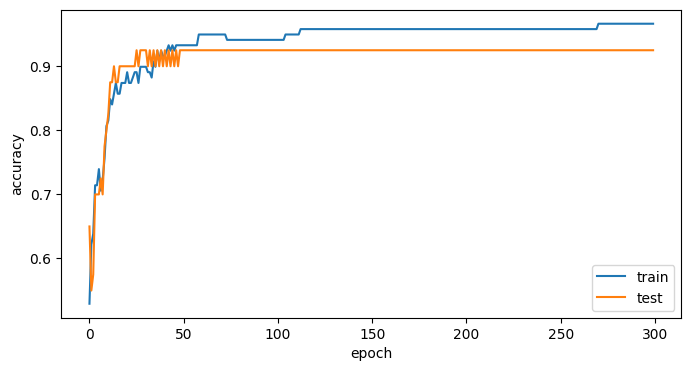

In [47]:
#최적의 epoch 찾기
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(train_score, label='train')
plt.plot(test_score,  label='test')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.show()

유방암 데이터셋 - scikit learn 에서 가져올수 있다.
